In [1]:
# Import library
import pandas as pd

# Load dataset
df = pd.read_csv("russia_ukraine_conflict.csv")

In [2]:
# 1. Select columns only
df = df[['event_id_cnty', 'event_date', 'event_type', 'sub_event_type', 'latitude', 'longitude', 'fatalities']]

In [3]:
# 2. Validate shape
print(df.shape)

(154251, 7)


In [4]:
# 3. Parse event date to correct data type
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')
print(df['event_date'].min(), df['event_date'].max())

2022-04-19 00:00:00 2025-04-18 00:00:00


In [5]:
# 4. Validate data type
print(df.dtypes)

event_id_cnty                str
event_date        datetime64[us]
event_type                   str
sub_event_type               str
latitude                 float64
longitude                float64
fatalities                 int64
dtype: object


In [6]:
# 5. Check for total missing values per column
print(df.isna().sum())

event_id_cnty     0
event_date        0
event_type        0
sub_event_type    0
latitude          0
longitude         0
fatalities        0
dtype: int64


In [7]:
# 6. Check if there's at least one duplicated row
print(df.duplicated().sum())

0


In [8]:
# 7. Check if there are any negative fatalities
print(df[df['fatalities'] < 0])

Empty DataFrame
Columns: [event_id_cnty, event_date, event_type, sub_event_type, latitude, longitude, fatalities]
Index: []


In [9]:
# 8. Check if there are any invalid geographic coordinates
print((~df['latitude'].between(-90, 90)).sum())
print((~df['longitude'].between(-180, 180)).sum())

0
0


In [10]:
# 9. Check for unexpected categories
print(df['event_type'].unique())
print(df['sub_event_type'].unique())

<StringArray>
['Explosions/Remote violence', 'Battles']
Length: 2, dtype: str
<StringArray>
[                   'Air/drone strike',                         'Armed clash',
   'Shelling/artillery/missile attack', 'Non-state actor overtakes territory',
       'Remote explosive/landmine/IED',        'Government regains territory',
                             'Grenade',                     'Chemical weapon',
                        'Suicide bomb']
Length: 9, dtype: str


In [11]:
# 10. Show the first 10 rows
df.head(10)

,event_id_cnty,event_date,event_type,sub_event_type,latitude,longitude,fatalities
0,UKR221613,2025-04-18,Explosions/Remote violence,Air/drone strike,51.7339,34.3415,0
1,UKR221717,2025-04-18,Battles,Armed clash,49.4758,37.7203,0
2,UKR221761,2025-04-18,Explosions/Remote violence,Shelling/artillery/missile attack,50.9208,35.3411,0
3,UKR221786,2025-04-18,Explosions/Remote violence,Air/drone strike,50.8508,35.3941,0
4,UKR221787,2025-04-18,Battles,Armed clash,49.6607,37.8615,0
5,UKR221604,2025-04-18,Battles,Armed clash,48.5008,37.9680,0
6,UKR221605,2025-04-18,Battles,Armed clash,48.0216,37.0568,9
7,UKR221606,2025-04-18,Explosions/Remote violence,Shelling/artillery/missile attack,46.6799,32.6925,3
8,UKR221607,2025-04-18,Explosions/Remote violence,Air/drone strike,52.2355,32.8243,0
9,UKR221608,2025-04-18,Explosions/Remote violence,Shelling/artillery/missile attack,47.9931,36.9391,2


In [12]:
# Import libraries for Chapter 3
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import scipy.stats as stats

In [13]:
# 3.1 Summary Statistics
df.groupby(['event_type', 'sub_event_type'])['fatalities'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)

count  mean  \
event_type                 sub_event_type                                     
Battles                    Armed clash                          38344  3.09   
                           Government regains territory           277  0.92   
                           Non-state actor overtakes territory    526  1.66   
Explosions/Remote violence Air/drone strike                     31601  0.39   
                           Chemical weapon                          1  0.00   
                           Grenade                                 18  0.33   
                           Remote explosive/landmine/IED         1412  0.56   
                           Shelling/artillery/missile attack    82070  0.36   
                           Suicide bomb                             2  2.00   

                                                                median    std  \
event_type                 sub_event_type                                       
Battles                    Armed clash                             0.0  13.37   
                           Government regains territory            0.0   7.34   
                           Non-state actor overtakes territory     0.0   7.45   
Explosions/Remote violence Air/drone strike                        0.0   3.95   
                           Chemical weapon                         0.0    NaN   
                           Grenade                                 0.0   0.49   
                           Remote explosive/landmine/IED           0.0   2.94   
                           Shelling/artillery/missile attack       0.0   4.58   
                           Suicide bomb                            2.0   1.41   

                                                                min  max  
event_type                 sub_event_type                                 
Battles                    Armed clash                            0  600  
                           Government regains territory           0  110  
                           Non-state actor overtakes territory    0  115  
Explosions/Remote violence Air/drone strike                       0  300  
                           Chemical weapon                        0    0  
                           Grenade                                0    1  
                           Remote explosive/landmine/IED          0   90  
                           Shelling/artillery/missile attack      0  500  
                           Suicide bomb                           1    3

In [14]:
variables = ['fatalities', 'latitude', 'longitude']
summary = pd.DataFrame(index=variables, columns=['Mean', 'Median', 'Mode', 'Range', 'Variance', 'Std Dev'])

for var in variables:
    summary.loc[var, 'Mean']     = df[var].mean()
    summary.loc[var, 'Median']   = df[var].median()
    summary.loc[var, 'Mode']     = df[var].mode()[0]
    summary.loc[var, 'Range']    = df[var].max() - df[var].min()
    summary.loc[var, 'Variance'] = df[var].var()
    summary.loc[var, 'Std Dev']  = df[var].std()

print(summary.astype(float).round(2))

             Mean  Median   Mode   Range  Variance  Std Dev
fatalities   1.05    0.00   0.00  600.00     60.51     7.78
latitude    48.77   48.38  46.66    8.95      2.29     1.51
longitude   36.09   36.85  32.62   17.41      4.08     2.02


In [15]:
# 3.2 Data Standardization
df['fatalities_z'] = stats.zscore(df['fatalities'])
df['latitude_z'] = stats.zscore(df['latitude'])
df['longitude_z'] = stats.zscore(df['longitude'])

print(df[['fatalities_z','latitude_z','longitude_z']].head(10))

   fatalities_z  latitude_z  longitude_z
0     -0.135193    1.957655    -0.866897
1     -0.135193    0.464815     0.805318
2     -0.135193    1.420111    -0.372181
3     -0.135193    1.373834    -0.345951
4     -0.135193    0.587053     0.875200
5     -0.135193   -0.179762     0.927908
6      1.021823   -0.496563     0.476943
7      0.250479   -1.383567    -1.683010
8     -0.135193    2.289265    -1.617780
9      0.121922   -0.515405     0.418692


In [16]:
# 3.3 Data Visualizations

Text(0, 0.5, 'Frequency')

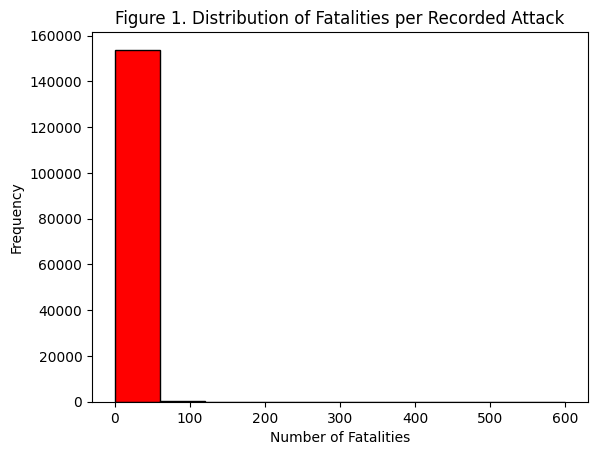

In [17]:
# Figure 1: Histogram — Distribution of Fatalities
counts, bins, _ = plt.hist(df['fatalities'], color='red', edgecolor='black')
plt.title("Figure 1. Distribution of Fatalities per Recorded Attack")
plt.xlabel("Number of Fatalities")
plt.ylabel("Frequency")

Text(0.5, 0, 'Number of Fatalities')

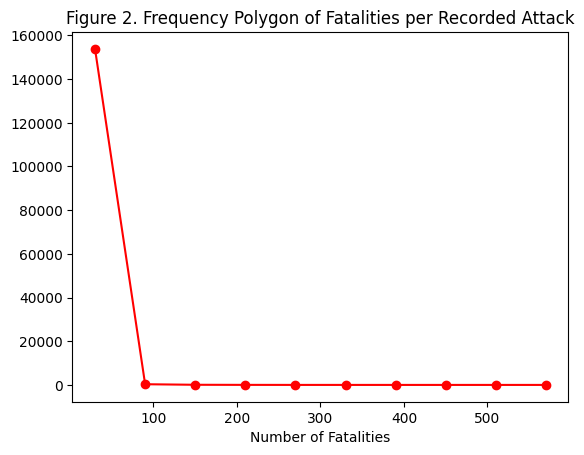

In [18]:
# Figure 2: Frequency Polygon — Distribution of Fatalities
midpoints = (bins[:-1] + bins[1:]) / 2
plt.plot(midpoints, counts, marker='o', color='red')
plt.title("Figure 2. Frequency Polygon of Fatalities per Recorded Attack")
plt.xlabel("Number of Fatalities")

(array([0, 1]),
 [Text(0, 0, 'Explosions/Remote violence'), Text(1, 0, 'Battles')])

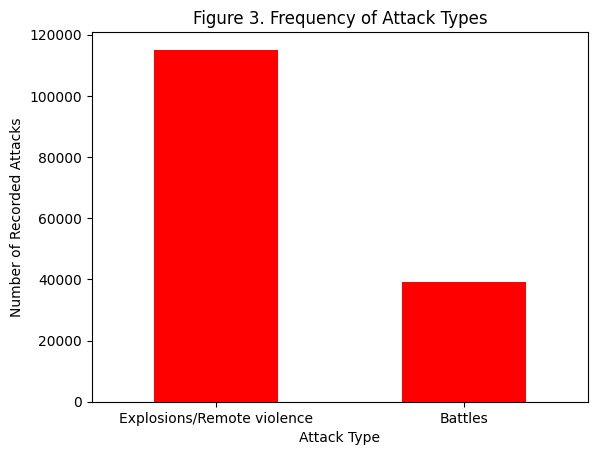

In [19]:
# Figure 3: Bar Chart — Frequency of Attack Types
event_counts = df['event_type'].value_counts()
event_counts.plot(kind='bar', color='red')
plt.title("Figure 3. Frequency of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Recorded Attacks")
plt.xticks(rotation=0)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Shelling/artillery/missile attack'),
  Text(1, 0, 'Armed clash'),
  Text(2, 0, 'Air/drone strike'),
  Text(3, 0, 'Remote explosive/landmine/IED'),
  Text(4, 0, 'Non-state actor overtakes territory'),
  Text(5, 0, 'Government regains territory'),
  Text(6, 0, 'Grenade'),
  Text(7, 0, 'Suicide bomb'),
  Text(8, 0, 'Chemical weapon')])

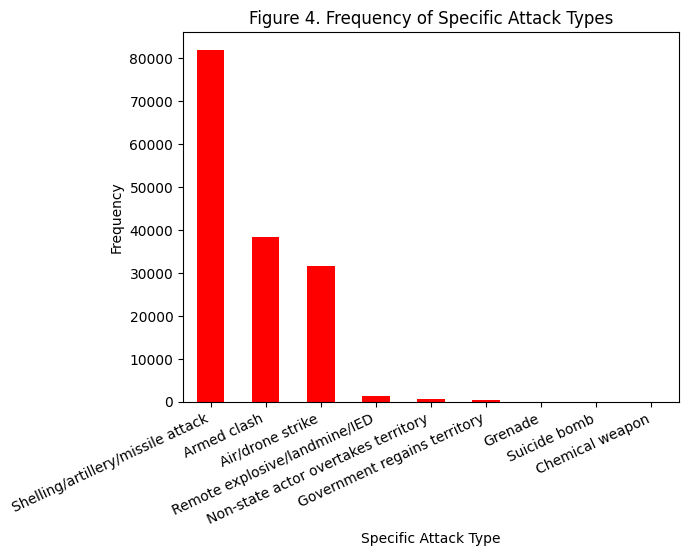

In [20]:
# Figure 4: Bar Chart — Frequency of Specific Attack Types
attack_counts = df['sub_event_type'].value_counts()
attack_counts.plot(kind='bar', color='red')
plt.title("Figure 4. Frequency of Specific Attack Types")
plt.xlabel("Specific Attack Type")
plt.ylabel("Frequency")
plt.xticks(rotation=25, ha='right')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Armed clash'),
  Text(1, 0, 'Suicide bomb'),
  Text(2, 0, 'Non-state actor overtakes territory'),
  Text(3, 0, 'Government regains territory'),
  Text(4, 0, 'Remote explosive/landmine/IED'),
  Text(5, 0, 'Air/drone strike'),
  Text(6, 0, 'Shelling/artillery/missile attack'),
  Text(7, 0, 'Grenade'),
  Text(8, 0, 'Chemical weapon')])

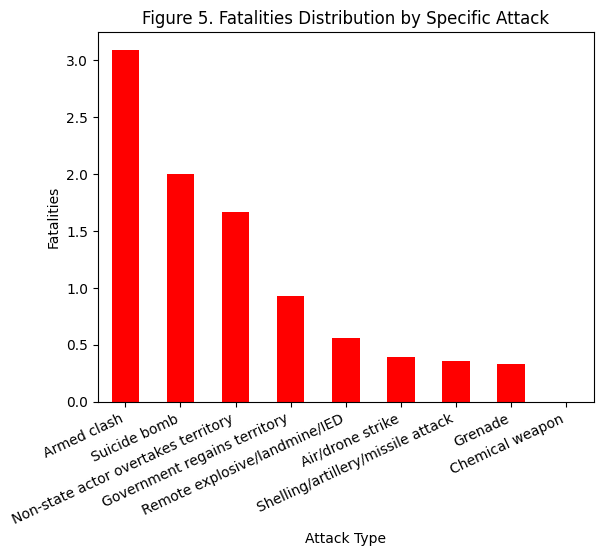

In [21]:
# Figure 5: Bar Chart — Fatalities Distribution by Specific Attack Type
event_counts = df.groupby('sub_event_type')['fatalities'].mean().sort_values(ascending=False)
event_counts.plot(kind='bar', color='red')
plt.title("Figure 5. Fatalities Distribution by Specific Attack")
plt.xlabel("Attack Type")
plt.ylabel("Fatalities")
plt.xticks(rotation=25, ha='right')

Text(0, 0.5, 'Latitude')

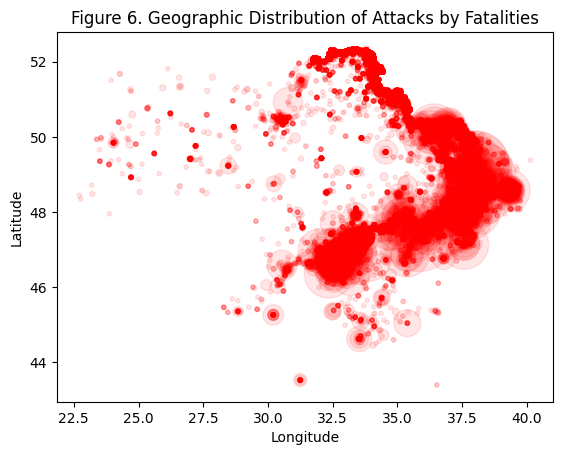

In [22]:
# Figure 6: Scatterplot — Geographic Distribution of Attacks
plt.scatter(
    df['longitude'],
    df['latitude'],
    s=df['fatalities']*5 + 10,
    color='red',
    alpha=0.1
)

plt.title('Figure 6. Geographic Distribution of Attacks by Fatalities')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [23]:
# 3.4 Distribution Analysis

In [24]:
# Fatalities
print("Skewness:", df['fatalities'].skew().round(2))
print("Kurtosis:", df['fatalities'].kurtosis().round(2))

Skewness: 27.22
Kurtosis: 1271.57


In [25]:
# Longitude
print("Skewness:", df['longitude'].skew().round(2))
print("Kurtosis:", df['longitude'].kurtosis().round(2))

Skewness: -1.0
Kurtosis: 0.67


In [26]:
# Latitude
print("Skewness:", df['latitude'].skew().round(2))
print("Kurtosis:", df['latitude'].kurtosis().round(2))

Skewness: 0.68
Kurtosis: -0.26


In [27]:
# 3.5 Correlation Analysis

In [28]:
# Pair 1: Latitude & Fatalities
r, p = stats.pearsonr(df['latitude'], df['fatalities'])

print("Pearson r:", r.round(4))
print("p-value:", p.round(4))

Pearson r: -0.0717
p-value: 0.0


In [29]:
# Pair 2: Longitude & Fatalities
r, p = stats.pearsonr(df['longitude'], df['fatalities'])

print("Pearson r:", r.round(4))
print("p-value:", p.round(4))

Pearson r: -0.0159
p-value: 0.0


In [30]:
# 3.6 Hypothesis Testing

In [31]:
# Hypothesis 2
groups = [
    group['fatalities'].values
    for name, group in df.groupby('sub_event_type')
]

F_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", F_stat.round(4))
print("p-value:", p_value.round(4))

F-statistic: 450.6825
p-value: 0.0


In [32]:
# Hypothesis 2. Degrees of Freedom
k = df['sub_event_type'].nunique()
N = len(df)

df_between = k - 1
df_within = N - k

print("df_between:", df_between)
print("df_within:", df_within)


df_between: 8
df_within: 154242


In [33]:
# 3.7 Regression Analysis
model = smf.ols(
    'fatalities ~ latitude + longitude + C(sub_event_type)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             fatalities   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     493.5
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:37:17   Log-Likelihood:            -5.3287e+05
No. Observations:              154251   AIC:                         1.066e+06
Df Residuals:                  154240   BIC:                         1.066e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [34]:
print("SSR:", round(sum(model.resid**2), 4))

SSR: 9043891.4759
